## Imports

In [5]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

from tools.params import Params, colors
import tools.viz.utilityTools as vizutils

import scipy.stats
import seaborn as sns
from tools.viz.rc_style import rc_context_talk


In [7]:
RESULTS_DIR = Path('/data/equake_results/pr_all_sessions/')
SESSIONS_ALL = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    "M061_2025_03_06_14_00",
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M063_2025_03_13_14_00',
    'M063_2025_03_14_15_30',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
]



In [36]:
for sess in SESSIONS_ALL:
    pkl_path = RESULTS_DIR / f'{sess}.pkl'
    with open(pkl_path, 'rb') as f:
        res = pickle.load(f)

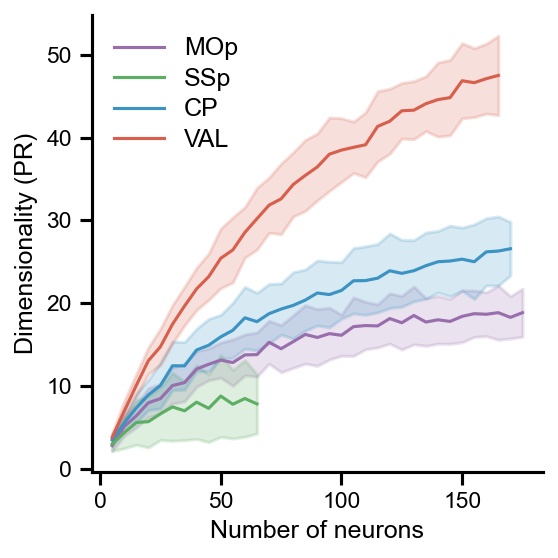

In [ ]:
with rc_context_talk():
    fig, ax = plt.subplots(figsize=(4, 4))
    for area in Params.areas:
        vizutils.shaded_errorbar(
            ax, res[area]['neurons'], res[area]['PR'],
            color=getattr(colors, f'{area}_light'),
            label=area,
            # errorStat=scipy.stats.sem,
        )
    ax.set_xlabel('Number of neurons')
    ax.set_ylabel('Dimensionality (PR)')
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

In [47]:
SESSIONS_ALL = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    "M061_2025_03_06_14_00",
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M063_2025_03_13_14_00',
    'M063_2025_03_14_15_30',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
]

EXCLUDE_AREAS = {
    'M062_2025_03_20_14_00': ['VAL'],
    'M062_2025_03_21_14_00': ['VAL', 'CP'],
    'M086_2025_12_10_15_00': ['VAL']
}


  EXCL VAL/M062_2025_03_20_14_00
  EXCL CP/M062_2025_03_21_14_00
  EXCL VAL/M062_2025_03_21_14_00
  EXCL VAL/M086_2025_12_10_15_00


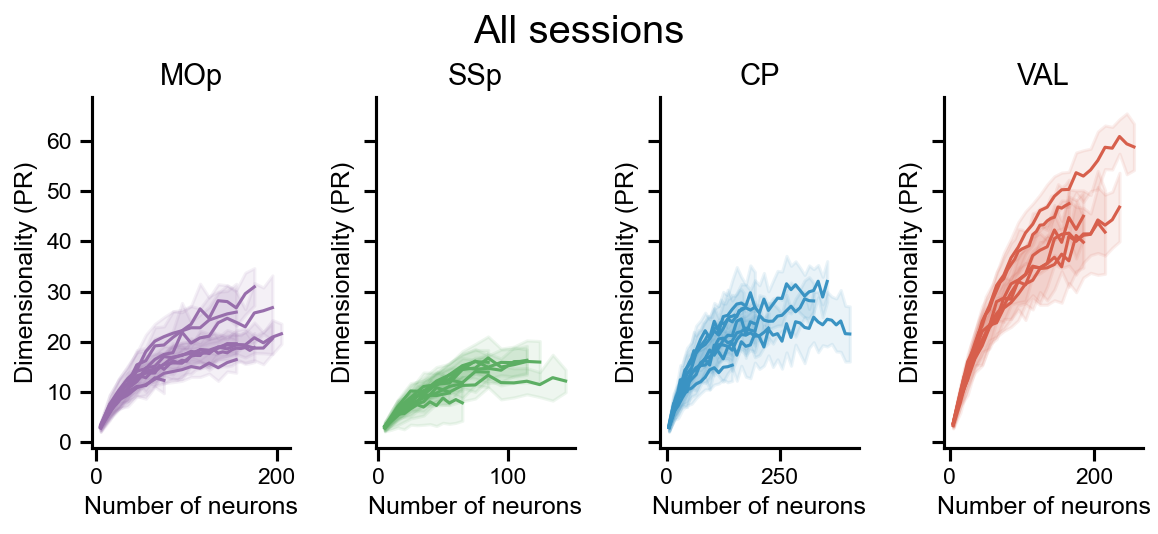

In [52]:
with rc_context_talk():
    fig, axs = plt.subplots(1, 4, figsize=(8, 4), sharey=True)
    for sess in SESSIONS_ALL:
        pkl_path = RESULTS_DIR / f'{sess}.pkl'
        try:
            with open(pkl_path, 'rb') as f:
                res = pickle.load(f)
        except:
            print(f'Session {sess} not found')

        
        for area, ax in zip(Params.areas, axs):
            if area in EXCLUDE_AREAS.get(sess, []):
                print(f'  EXCL {area}/{sess}')
                continue
            vizutils.shaded_errorbar(
                ax, res[area]['neurons'], res[area]['PR'],
                color=getattr(colors, f'{area}_light'),
                label=area,
                # errorStat=scipy.stats.sem,
                alpha_err=0.1
            )
            ax.set_xlabel('Number of neurons')
            ax.set_ylabel('Dimensionality (PR)')

            # ax.legend()
            ax.set_title(area)
        plt.suptitle('All sessions', y=0.9)
        plt.tight_layout()


    plt.show()